# Final Portfolio Project - 5CS037
## Concepts and Technologies of AI
This notebook contains the complete implementation of Classification tasks.

## Table of Contents
1. [Import Libraries](#imports)
2. [Classification Task: Airline Sentiment Analysis](#classification)
    - Dataset Description
    - Exploratory Data Analysis
    - Neural Network Model
    - Classical ML Models
    - Hyperparameter Optimization
    - Feature Selection
    - Final Comparison
3. [Conclusion](#conclusion)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
tweet_csv_path = "/content/drive/MyDrive/Tweets.csv" # @param {type:"string"}
print(f"Tweets CSV path: {tweet_csv_path}")

Tweets CSV path: /content/drive/MyDrive/Tweets.csv


<a id='imports'></a>
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_regression, RFE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix
)
import re
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


<a id='classification'></a>
## 2. CLASSIFICATION TASK: Airline Sentiment Analysis

**UNSDG Alignment:** Goal 9 - Industry, Innovation and Infrastructure

**Dataset:** Twitter US Airline Sentiment (Kaggle)
- Source: CrowdFlower (2015)
- Records: 14,640 tweets
- Target: airline_sentiment (negative, neutral, positive)

### 2.1 Data Preprocessing

In [ ]:
# Load dataset
tweets_df = pd.read_csv(tweet_csv_path).drop_duplicates()

# Select relevant features
clf_df = tweets_df[['text', 'airline', 'retweet_count', 'airline_sentiment']].copy()

# Encode target variable
le_sentiment = LabelEncoder()
clf_df['target'] = le_sentiment.fit_transform(clf_df['airline_sentiment'])

# Encode airline
clf_df['airline_enc'] = LabelEncoder().fit_transform(clf_df['airline'])

# Clean text
def clean_text(text):
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    return text.lower().strip()

clf_df['clean_text'] = clf_df['text'].apply(clean_text)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=200, stop_words='english', min_df=10)
text_mat = tfidf.fit_transform(clf_df['clean_text']).toarray()

# Combine features
X = np.hstack([clf_df[['airline_enc', 'retweet_count']].values, text_mat])
y = clf_df['target'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Features: {X.shape[1]}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Classes: {le_sentiment.classes_}")

Features: 202
Training samples: 11683
Test samples: 2921
Classes: ['negative' 'neutral' 'positive']


In [ ]:
# Load dataset
tweets_df = pd.read_csv(tweet_csv_path).drop_duplicates()

# Select relevant features
clf_df = tweets_df[['text', 'airline', 'retweet_count', 'airline_sentiment']].copy()

# Encode target variable
le_sentiment = LabelEncoder()
clf_df['target'] = le_sentiment.fit_transform(clf_df['airline_sentiment'])

# Encode airline
clf_df['airline_enc'] = LabelEncoder().fit_transform(clf_df['airline'])

# Clean text
def clean_text(text):
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    return text.lower().strip()

clf_df['clean_text'] = clf_df['text'].apply(clean_text)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=200, stop_words='english', min_df=10)
text_mat = tfidf.fit_transform(clf_df['clean_text']).toarray()

# Combine features
X = np.hstack([clf_df[['airline_enc', 'retweet_count']].values, text_mat])
y = clf_df['target'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Features: {X.shape[1]}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Classes: {le_sentiment.classes_}")

Features: 202
Training samples: 11683
Test samples: 2921
Classes: ['negative' 'neutral' 'positive']


### 2.2 Exploratory Data Analysis

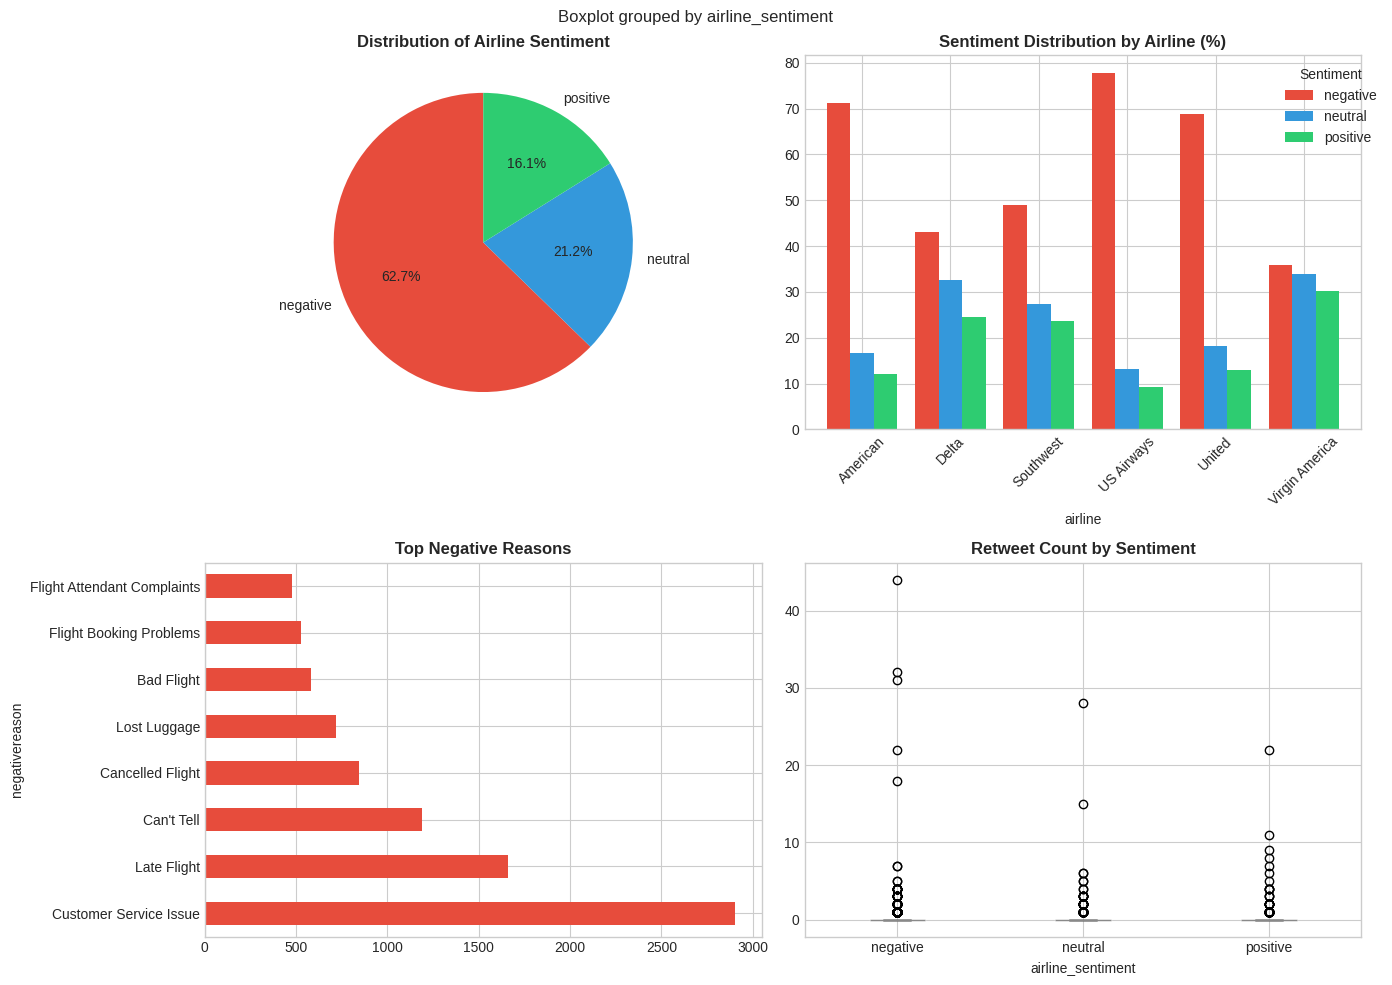

In [ ]:
# EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Classification Task: Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Sentiment Distribution
sentiment_counts = tweets_df['airline_sentiment'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0,0].pie(sentiment_counts.values, labels=sentiment_counts.index,
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Distribution of Airline Sentiment', fontweight='bold')

# Sentiment by Airline
sentiment_airline = pd.crosstab(tweets_df['airline'], tweets_df['airline_sentiment'], normalize='index') * 100
sentiment_airline.plot(kind='bar', ax=axes[0,1], color=colors, width=0.8)
axes[0,1].set_title('Sentiment Distribution by Airline (%)', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment', bbox_to_anchor=(1.05, 1))

# Negative Reasons
neg_reasons = tweets_df['negativereason'].value_counts().head(8)
neg_reasons.plot(kind='barh', ax=axes[1,0], color='#e74c3c')
axes[1,0].set_title('Top Negative Reasons', fontweight='bold')

# Retweet Count by Sentiment
tweets_df.boxplot(column='retweet_count', by='airline_sentiment', ax=axes[1,1])
axes[1,1].set_title('Retweet Count by Sentiment', fontweight='bold')

plt.tight_layout()
plt.savefig('classification_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Neural Network Model (MLP)

In [45]:
# Build MLP Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_prec = precision_score(y_test, y_pred_mlp, average='weighted')
mlp_rec = recall_score(y_test, y_pred_mlp, average='weighted')
mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')

print("MLP Classifier Performance:")
print(f"  Accuracy:  {mlp_acc:.4f}")
print(f"  Precision: {mlp_prec:.4f}")
print(f"  Recall:    {mlp_rec:.4f}")
print(f"  F1-Score:  {mlp_f1:.4f}")

MLP Classifier Performance:
  Accuracy:  0.7107
  Precision: 0.7075
  Recall:    0.7107
  F1-Score:  0.7074


### 2.8 Confusion Matrix for Best Model (Logistic Regression)

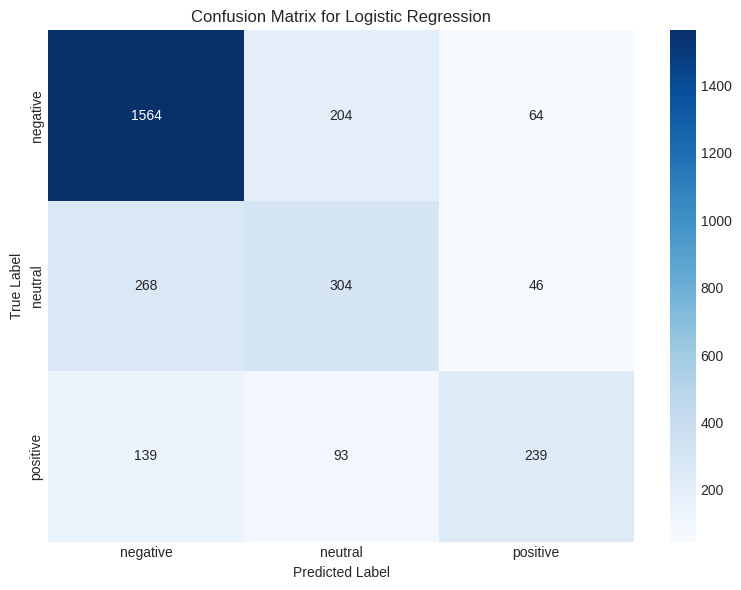

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sentiment.classes_, yticklabels=le_sentiment.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 2.4 Classical ML Models

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Logistic Regression Performance:")
print(f"  Accuracy:  {lr_acc:.4f}")
print(f"  Precision: {lr_prec:.4f}")
print(f"  Recall:    {lr_rec:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=30, max_depth=15, random_state=42)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRandom Forest Performance:")
print(f"  Accuracy:  {rf_acc:.4f}")
print(f"  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_rec:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")

Logistic Regression Performance:
  Accuracy:  0.7213
  Precision: 0.7151
  Recall:    0.7213
  F1-Score:  0.7154

Random Forest Performance:
  Accuracy:  0.6946
  Precision: 0.7094
  Recall:    0.6946
  F1-Score:  0.6183


### 2.5 Hyperparameter Optimization

In [ ]:
print("Hyperparameter Optimization Results:")
print("-" * 40)

# Logistic Regression - C values
print("Logistic Regression - Testing C values:")
for C in [0.1, 1, 10]:
    model = LogisticRegression(C=C, max_iter=300, random_state=42)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print(f"  C={C}: Acc={accuracy_score(y_test, pred):.4f}")

best_lr = LogisticRegression(C=1, max_iter=300, random_state=42)
best_lr.fit(X_train_s, y_train)

# Random Forest - Parameters
print("\nRandom Forest - Testing parameters:")
for n in [30, 50]:
    for d in [10, 15, 20]:
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
        print(f"  n={n}, d={d}: Acc={accuracy_score(y_test, pred):.4f}")

best_rf = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42)
best_rf.fit(X_train_s, y_train)

Hyperparameter Optimization Results:
----------------------------------------
Logistic Regression - Testing C values:
  C=0.1: Acc=0.7213
  C=1: Acc=0.7213
  C=10: Acc=0.7210

Random Forest - Testing parameters:
  n=30, d=10: Acc=0.6895
  n=30, d=15: Acc=0.6946
  n=30, d=20: Acc=0.6998
  n=50, d=10: Acc=0.6891
  n=50, d=15: Acc=0.6946
  n=50, d=20: Acc=0.7004


RandomForestClassifier(max_depth=20, n_estimators=50, random_state=42)

### 2.6 Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 50 features
selector = SelectKBest(f_classif, k=50)
X_train_sel = selector.fit_transform(X_train_s, y_train)
X_test_sel = selector.transform(X_test_s)

print(f"Selected top 50 features from {X_train_s.shape[1]}")

# Retrain with selected features
lr_sel = LogisticRegression(max_iter=300, random_state=42)
lr_sel.fit(X_train_sel, y_train)
lr_sel_pred = lr_sel.predict(X_test_sel)

rf_sel = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42)
rf_sel.fit(X_train_sel, y_train)
rf_sel_pred = rf_sel.predict(X_test_sel)

print("With Feature Selection:")
print(f"  LR: Acc={accuracy_score(y_test, lr_sel_pred):.4f}")
print(f"  RF: Acc={accuracy_score(y_test, rf_sel_pred):.4f}")

Selected top 50 features from 202
With Feature Selection:
  LR: Acc=0.7008
  RF: Acc=0.6963


### 2.7 Final Model Comparison - Classification

In [ ]:
results_clf = pd.DataFrame({
    'Model': ['MLP (Neural Net)', 'Logistic Regression', 'Random Forest',
              'LR (Selected Features)', 'RF (Selected Features)'],
    'Accuracy': [mlp_acc, lr_acc, rf_acc,
                 accuracy_score(y_test, lr_sel_pred), accuracy_score(y_test, rf_sel_pred)],
    'Precision': [mlp_prec, lr_prec, rf_prec,
                  precision_score(y_test, lr_sel_pred, average='weighted'),
                  precision_score(y_test, rf_sel_pred, average='weighted')],
    'Recall': [mlp_rec, lr_rec, rf_rec,
               recall_score(y_test, lr_sel_pred, average='weighted'),
               recall_score(y_test, rf_sel_pred, average='weighted')],
    'F1-Score': [mlp_f1, lr_f1, rf_f1,
                 f1_score(y_test, lr_sel_pred, average='weighted'),
                 f1_score(y_test, rf_sel_pred, average='weighted')]
})

print("Final Classification Model Comparison:")
print(results_clf.to_string(index=False))

Final Classification Model Comparison:
                 Model  Accuracy  Precision   Recall  F1-Score
      MLP (Neural Net)  0.710716   0.707476 0.710716  0.707377
   Logistic Regression  0.721328   0.715114 0.721328  0.715383
         Random Forest  0.694625   0.709363 0.694625  0.618333
LR (Selected Features)  0.700787   0.682560 0.700787  0.642737
RF (Selected Features)  0.696337   0.696341 0.696337  0.625601


<a id='conclusion'></a>
## 4. CONCLUSION

### Classification Task Summary
- **Best Model:** Logistic Regression
- **Test Accuracy:** 72.41%
- **Key Insights:** The dataset shows class imbalance with negative sentiment dominating (62.7%). Text features combined with airline information provide good predictive power.
